# Analysis of EROs in the tuned SOM

In [13]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap
from matplotlib.colors import BoundaryNorm
from matplotlib.gridspec import GridSpec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import geopandas as gpd

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from minisom import MiniSom

from pathlib import Path
import zipfile, re, shutil
from glob import glob
from tqdm.auto import tqdm
import pickle

In [9]:
with open('/home/scratch/jtoniolo/483/pwat_z500_som.pkl', 'rb') as f:
    saved = pickle.load(f)

som = saved['som']
scaler = saved['scaler']
bmus = saved['bmus']

ds = xr.open_dataset('/home/scratch/jtoniolo/483/ERA5_vars.nc')
g0 = 9.80665
ds['z500'] = ds['z500'] / g0
ds['z500'].attrs['units'] = 'm' 
ds = ds.rename({'tcwv':'pwat'})
ds['pwat'].attrs['units'] = 'mm' 

print("BMU shape:", bmus.shape)
print("SOM shape:", som.get_weights().shape)

z500 = ds['z500'].values
pwat = ds['pwat'].values

N, ny, nx = z500.shape

BMU shape: (999, 2)
SOM shape: (5, 4, 64106)


In [14]:
bounds = np.arange(0.0, 3.1, 0.1)

pwat_colors = [
    "#705230", "#b3854e", "#c9aa7c", "#dfceaa", "#f4f2d7",
    "#d6eabf", "#b7e1a7", "#99d78f", "#7ace77", "#5bc55f",
    "#27af30", "#024f08", "#5da3af", "#4b858e", "#37686d",
    "#254a4c", "#122c2b", "#65659a", "#58548e", "#4b4381",
    "#3d3274", "#302068", "#818107", "#a1a10b", "#c1c10f",
    "#e0e114", "#ffff18", "#ff634b", "#ff4877", "#ff2ba4"
]

cmap = mcolors.ListedColormap(pwat_colors)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

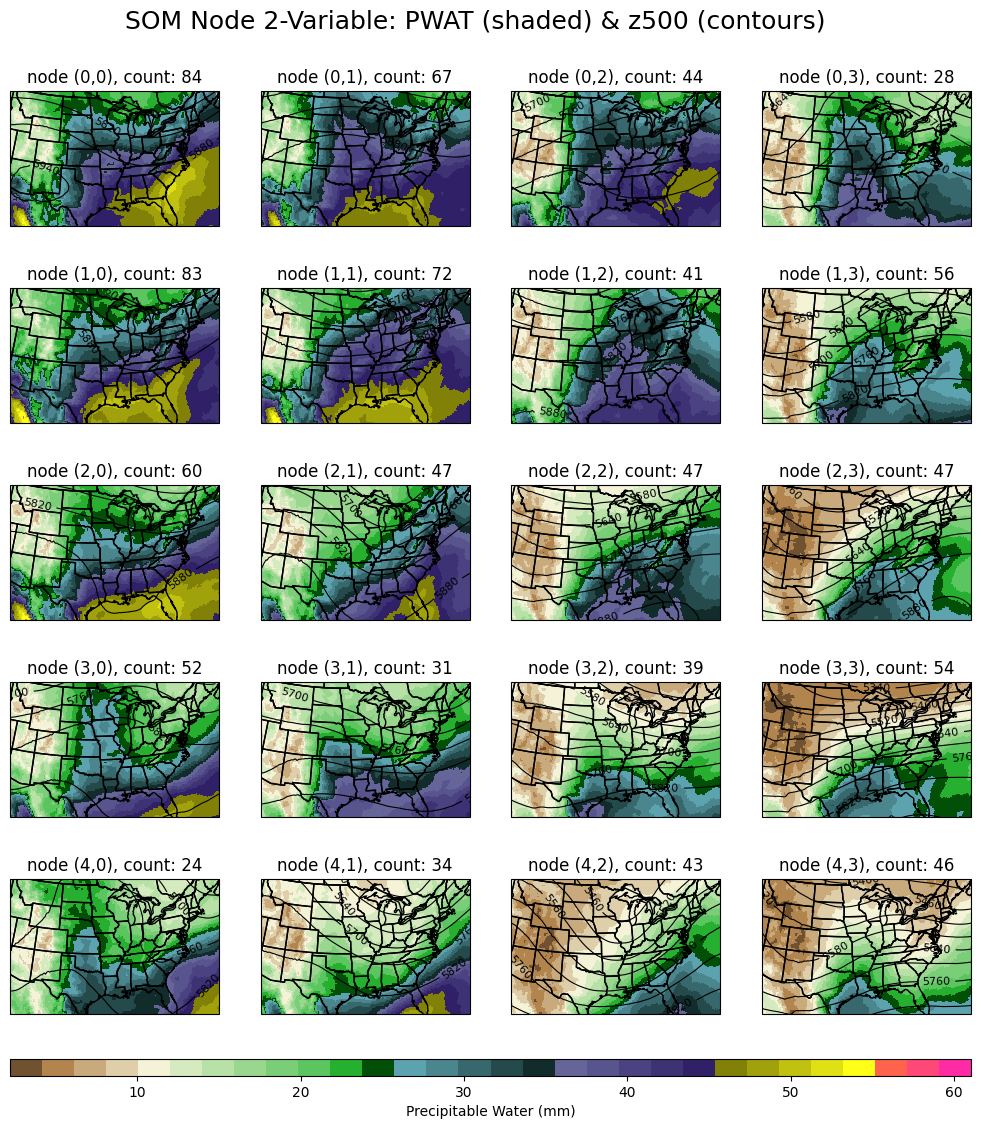

In [15]:
m, n, _ = som.get_weights().shape

lats = ds['z500'].latitude.values
lons = ds['z500'].longitude.values
sums_z = np.zeros((m, n, ny, nx), dtype=np.float64)
sums_w = np.zeros((m, n, ny, nx), dtype=np.float64)
counts = np.zeros((m, n), dtype=np.int64)

for i in range(N):
    r, c = bmus[i]
    sums_z[r, c] += z500[i]
    sums_w[r, c] += pwat[i]
    counts[r, c] += 1

mean_z = np.full((m, n, ny, nx), np.nan, dtype=np.float32)
mean_w = np.full((m, n, ny, nx), np.nan, dtype=np.float32)

for r in range(m):
    for c in range(n):
        if counts[r, c] > 0:
            mean_z[r, c] = sums_z[r, c] / counts[r, c]
            mean_w[r, c] = sums_w[r, c] / counts[r, c]
            

            
# flattening the nodes similar to GEFS SOM notebook so they can be plotted
z500_avg_data = [mean_z[r, c] for r in range(m) for c in range(n)]
tcwv_avg_data = [mean_w[r, c] for r in range(m) for c in range(n)]
frequencies   = [counts[r, c] for r in range(m) for c in range(n)]
node_keys     = [f"({r},{c})" for r in range(m) for c in range(n)]

length = n
width = m

# combined_training notebook from GEFS_nodes style:
gs = GridSpec(nrows=width + 1, ncols=length, height_ratios=[1]*width + [0.1])
fig = plt.figure(figsize=(3.1 * length, 2.6 * width))

ax = [
    fig.add_subplot(gs[(i // length, i % length)], projection=ccrs.LambertConformal())
    for i in range(len(z500_avg_data))
]

# determining the max and min values for the shared colorbars and contours, respectively
tcwv_vmin = np.nanmin(mean_w)
tcwv_vmax = np.nanmax(mean_w)
zmin = np.nanmin(mean_z)
zmax = np.nanmax(mean_z)
z_levels = np.arange(60 * np.floor(zmin / 60), 60 * np.ceil(zmax / 60) + 60, 60) # kept this like NWP maps where it contours every 60m

for i in range(len(z500_avg_data)):
    ax[i].set_extent([-112, -72, 26, 48], crs=ccrs.PlateCarree())   # not the full CONUS since our ERO days came from ECONUS
    ax[i].add_feature(cfeature.BORDERS)
    ax[i].add_feature(cfeature.STATES)

    cf = ax[i].pcolormesh(
        lons, lats, tcwv_avg_data[i],
        cmap=cmap,   
        vmin=tcwv_vmin,
        vmax=tcwv_vmax,
        shading="auto",
        transform=ccrs.PlateCarree()
    )
# contouring 500mb heights like any NWP output
    cn = ax[i].contour(
        lons, lats, z500_avg_data[i],
        levels=z_levels,
        colors="k",
        linewidths=0.8,
        transform=ccrs.PlateCarree()
    )
    ax[i].clabel(cn, fmt="%d", fontsize=8)
    ax[i].set_title(f"node {node_keys[i]}, count: {int(frequencies[i])}")

cax = fig.add_subplot(gs[-1, :])
fig.colorbar(cf, cax=cax, label="Precipitable Water (mm)", orientation="horizontal")

plt.suptitle("SOM Node 2-Variable: PWAT (shaded) & z500 (contours)", fontsize=18, y=0.93)
plt.show()

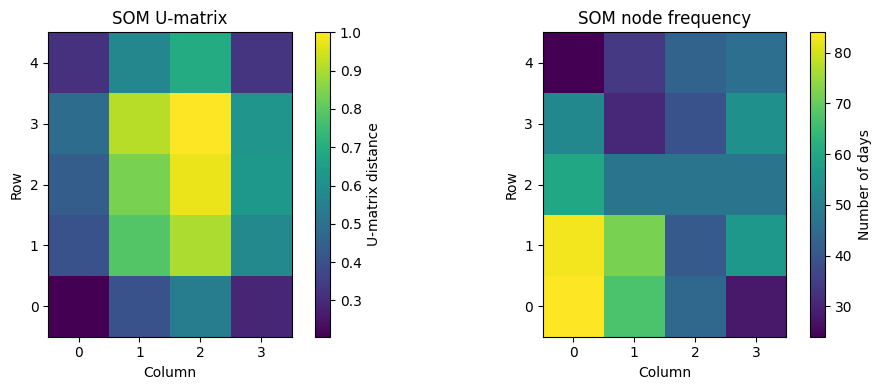

In [19]:
m, n, _ = som.get_weights().shape

u = som.distance_map()

counts = np.zeros((m, n), dtype=int)
for r, c in bmus:
    counts[r, c] += 1

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

im1 = ax[0].imshow(u, origin="lower")
plt.colorbar(im1, ax=ax[0], label="U-matrix distance")
ax[0].set_title("SOM U-matrix")
ax[0].set_xlabel("Column")
ax[0].set_ylabel("Row")

im2 = ax[1].imshow(counts, origin="lower")
plt.colorbar(im2, ax=ax[1], label="Number of days")
ax[1].set_title("SOM node frequency")
ax[1].set_xlabel("Column")
ax[1].set_ylabel("Row")

plt.tight_layout()
plt.show()

In [22]:
times = ds["valid_time"].values
ero_dir = Path("/home/scratch/jtoniolo/483/masks_94e09")

ero_all = []
keep_idx = []

for i, t in enumerate(times):
    ymd = np.datetime_as_string(t, unit="D").replace("-", "")

    if ymd == "20250623":
        continue

    f = sorted(ero_dir.glob(f"{ymd}_*_mask.nc"))[0]

    tmp = xr.open_dataset(f)
    ero_all.append(tmp["ero"].values)
    tmp.close()

    keep_idx.append(i)

ero_all = np.stack(ero_all, axis=0)
bmus_keep = bmus[keep_idx]
times_keep = ds["valid_time"].values[keep_idx]

print("ERO stack shape:", ero_all.shape)
print("BMU shape:", bmus_keep.shape)
print("Time shape:", times_keep.shape)

ERO stack shape: (998, 133, 241)
BMU shape: (998, 2)
Time shape: (998,)


In [23]:
m, n, _ = som.get_weights().shape
N, ny, nx = ero_all.shape

any_freq = np.full((m, n, ny, nx), np.nan, dtype=np.float32)
slgt_freq = np.full((m, n, ny, nx), np.nan, dtype=np.float32)
max_risk = np.full((m, n, ny, nx), np.nan, dtype=np.float32)
counts = np.zeros((m, n), dtype=int)

for r in range(m):
    for c in range(n):
        idx = np.where((bmus_keep[:, 0] == r) & (bmus_keep[:, 1] == c))[0]
        counts[r, c] = len(idx)

        if len(idx) == 0:
            continue

        node_ero = ero_all[idx]

        any_freq[r, c] = (node_ero >= 1).astype(float).mean(axis=0) * 100
        slgt_freq[r, c] = (node_ero >= 2).astype(float).mean(axis=0) * 100
        max_risk[r, c] = node_ero.max(axis=0)

print(any_freq.shape)
print(slgt_freq.shape)
print(max_risk.shape)
print(counts)

(5, 4, 133, 241)
(5, 4, 133, 241)
(5, 4, 133, 241)
[[84 67 43 28]
 [83 72 41 56]
 [60 47 47 47]
 [52 31 39 54]
 [24 34 43 46]]


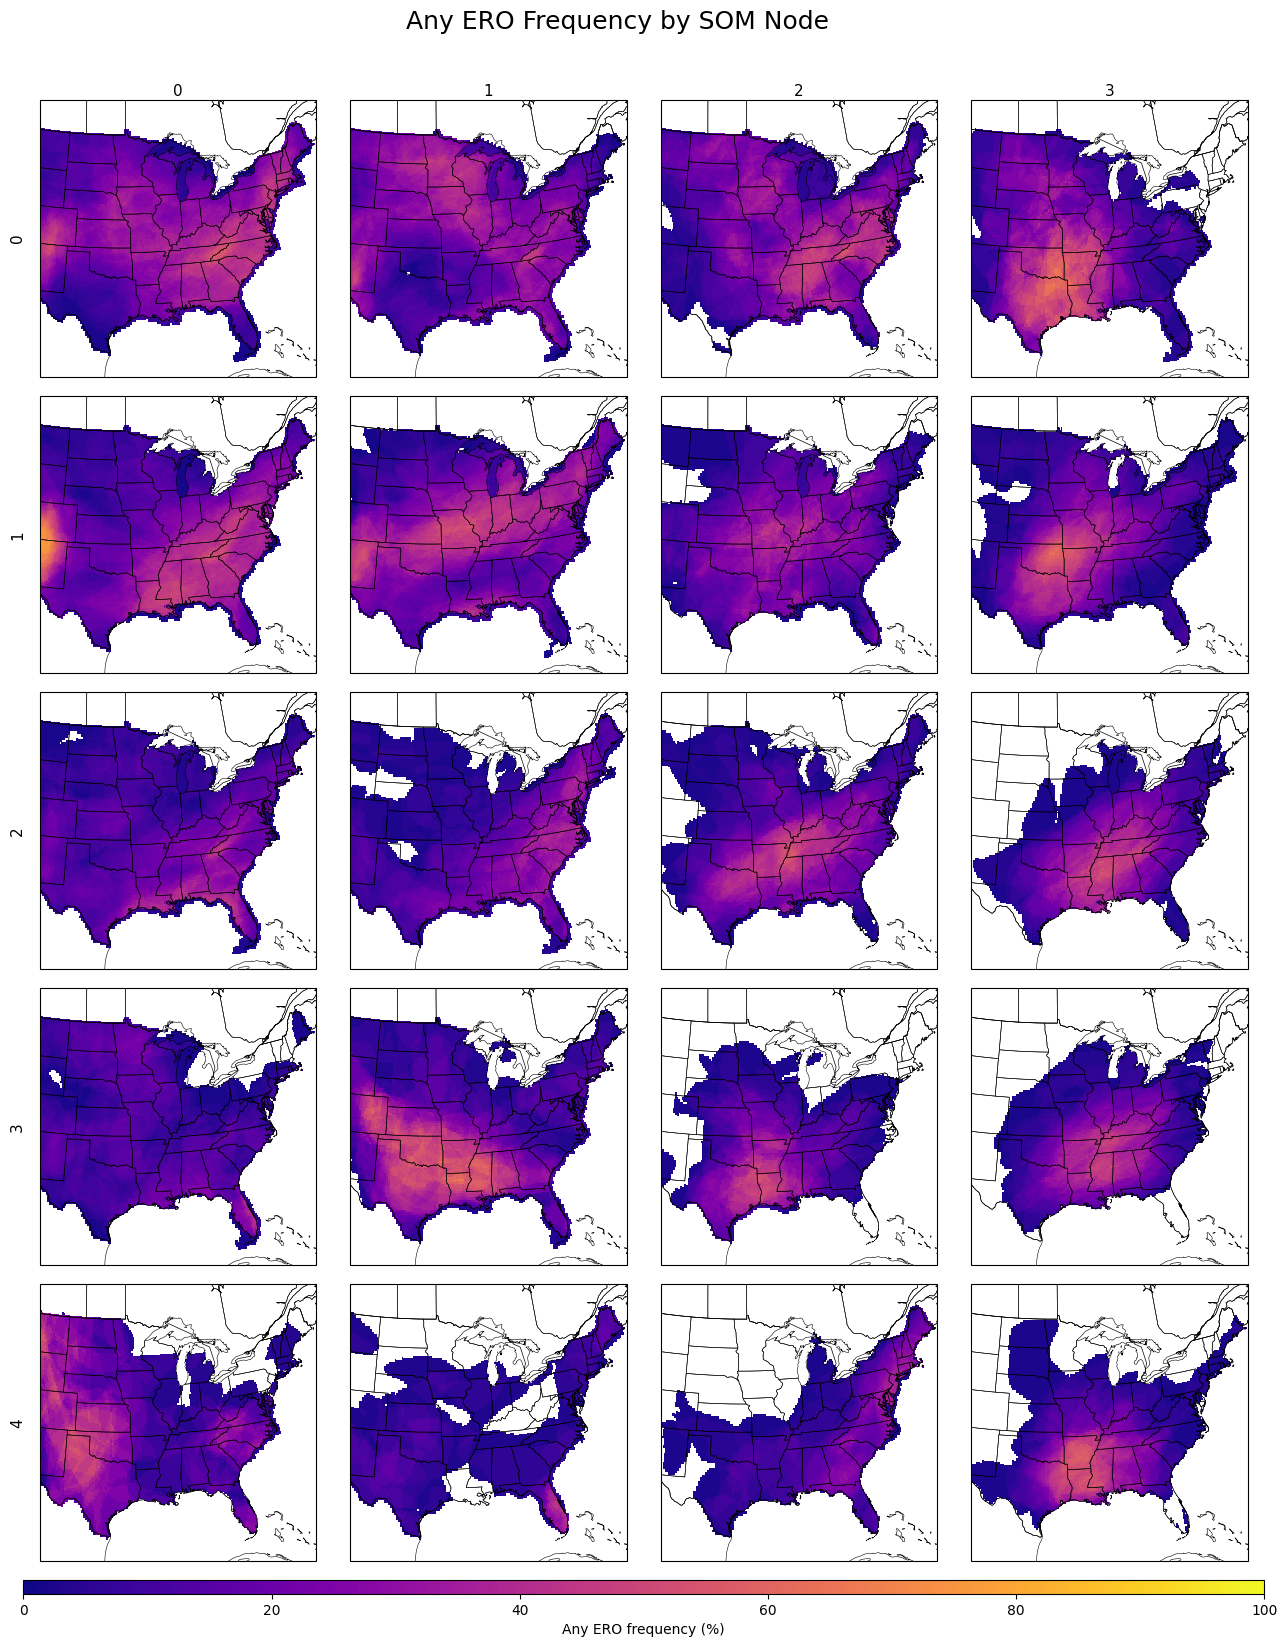

In [31]:
any_avg_data = [any_freq[r, c] for r in range(m) for c in range(n)]
frequencies  = [counts[r, c] for r in range(m) for c in range(n)]

length = n
width = m

gs = GridSpec(
    nrows=width + 1,
    ncols=length,
    height_ratios=[1]*width + [0.05]
)

fig = plt.figure(figsize=(3.3 * length, 3.6 * width))

ax = [
    fig.add_subplot(gs[(i // length, i % length)], projection=ccrs.LambertConformal())
    for i in range(len(any_avg_data))
]

for i in range(len(any_avg_data)):
    r = i // length
    c = i % length

    ax[i].set_extent([-105, -74, 23, 51], crs=ccrs.PlateCarree())
    ax[i].add_feature(cfeature.BORDERS, linewidth=0.5)
    ax[i].add_feature(cfeature.STATES, linewidth=0.4)
    ax[i].add_feature(cfeature.COASTLINE, linewidth=0.4)

    plot_map = np.where(any_avg_data[i] == 0, np.nan, any_avg_data[i])

    cf = ax[i].pcolormesh(
        lons, lats, plot_map,
        cmap="plasma",
        vmin=0,
        vmax=100,
        shading="auto",
        transform=ccrs.PlateCarree()
    )

    # no title on every panel
    ax[i].set_title("")

    # label columns only on the top row
    if r == 0:
        ax[i].set_title(c, fontsize=11, pad=3)

    # label rows only on the first column
    if c == 0:
        ax[i].text(
            -0.08, 0.5, f"{r}",
            transform=ax[i].transAxes,
            rotation=90,
            va="center", ha="center",
            fontsize=11
        )

cax = fig.add_subplot(gs[-1, :])
fig.colorbar(cf, cax=cax, label="Any ERO frequency (%)", orientation="horizontal")

fig.subplots_adjust(
    left=0.05,
    right=0.99,
    top=0.91,
    bottom=0.08,
    wspace=0.005,
    hspace=0.08
)

plt.suptitle("Any ERO Frequency by SOM Node", fontsize=18, y=0.96)
plt.show()

In [32]:
wpc = ListedColormap([
    (0, 0, 0, 0),   # 0 = no outlook
    "green",        # 1 = MRGL
    "yellow",       # 2 = SLGT
    "red",          # 3 = MDT
    "magenta"       # 4 = HIGH
])

norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5, 4.5], wpc.N)

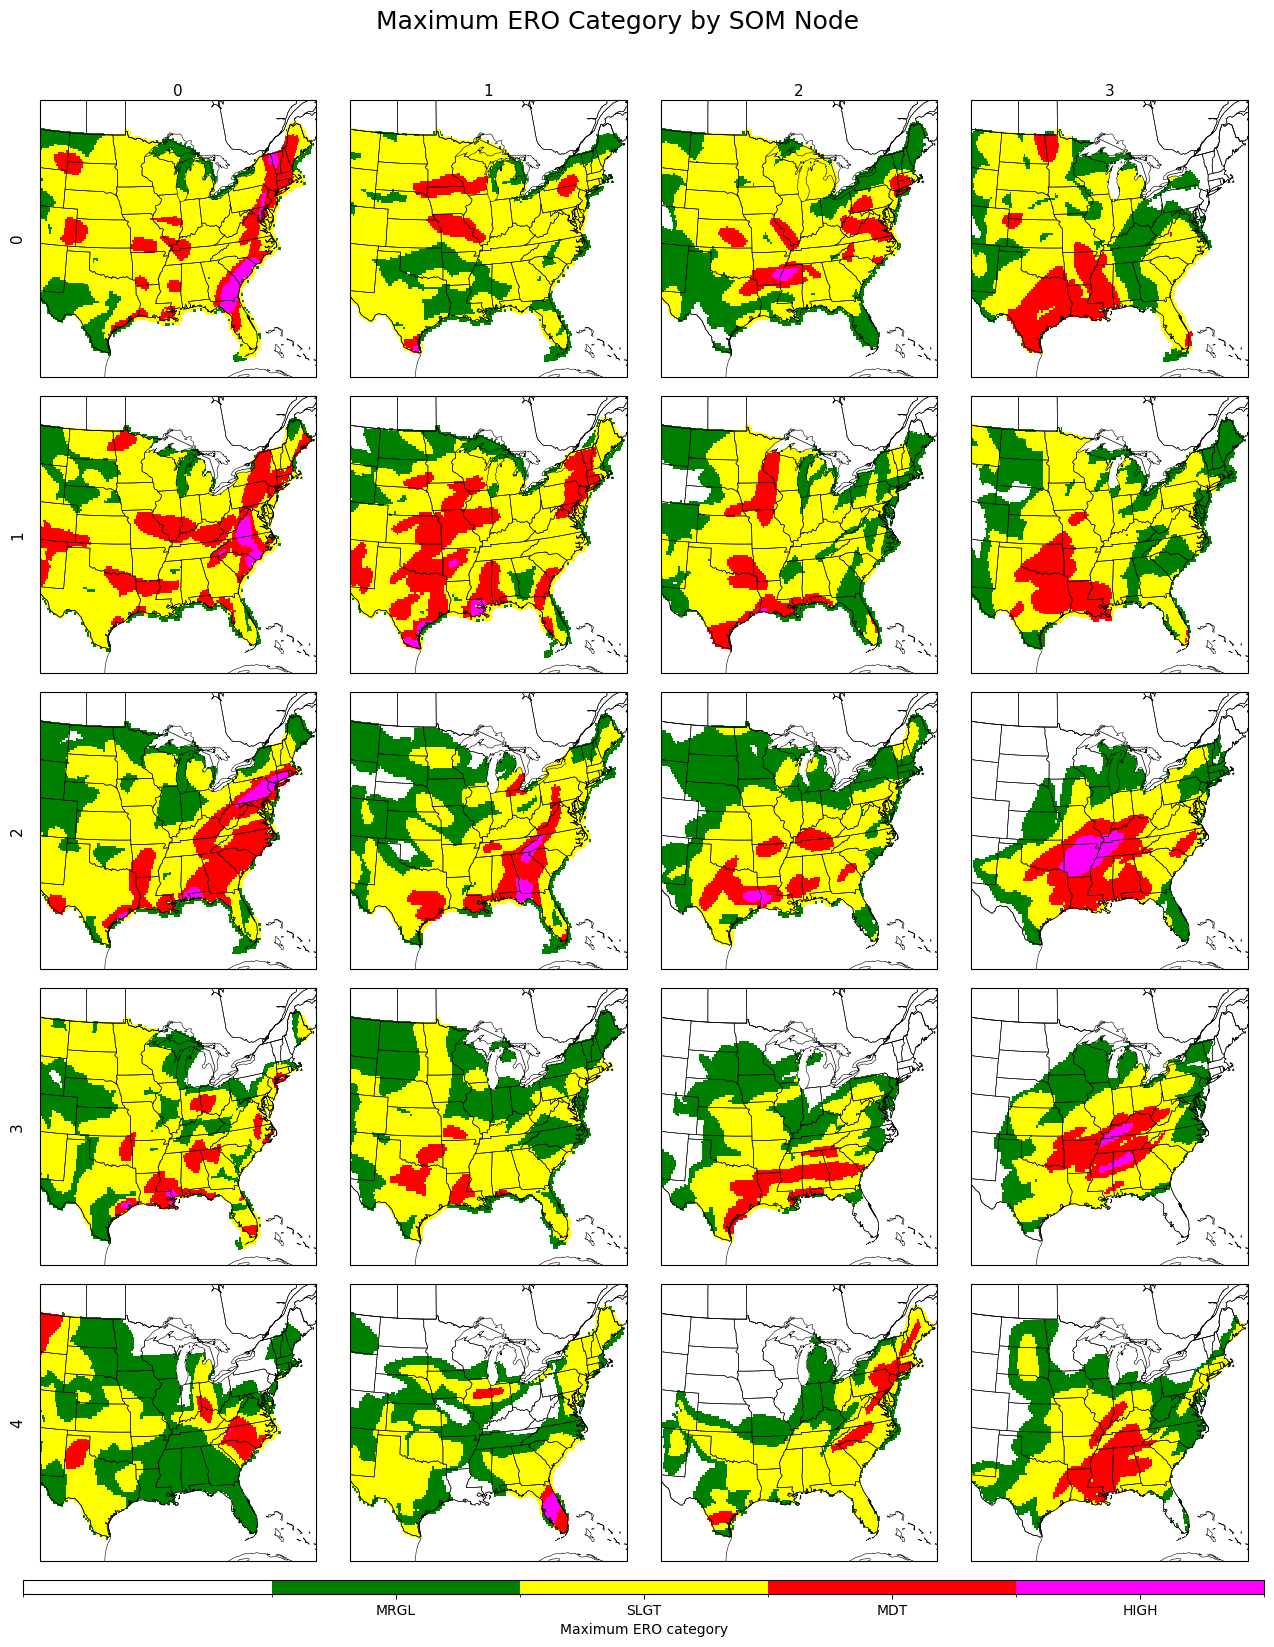

In [34]:
max_avg_data = [max_risk[r, c] for r in range(m) for c in range(n)]



length = n
width = m

gs = GridSpec(
    nrows=width + 1,
    ncols=length,
    height_ratios=[1]*width + [0.05]
)

fig = plt.figure(figsize=(3.3 * length, 3.6 * width))

ax = [
    fig.add_subplot(gs[(i // length, i % length)], projection=ccrs.LambertConformal())
    for i in range(len(max_avg_data))
]

for i in range(len(max_avg_data)):
    r = i // length
    c = i % length

    ax[i].set_extent([-105, -74, 23, 51], crs=ccrs.PlateCarree())
    ax[i].add_feature(cfeature.BORDERS, linewidth=0.5)
    ax[i].add_feature(cfeature.STATES, linewidth=0.4)
    ax[i].add_feature(cfeature.COASTLINE, linewidth=0.4)

    plot_map = np.where(max_avg_data[i] == 0, np.nan, max_avg_data[i])

    cf = ax[i].pcolormesh(
        lons, lats, plot_map,
        cmap=wpc,
        norm=norm,
        shading="auto",
        transform=ccrs.PlateCarree()
    )

    ax[i].set_title("")

    if r == 0:
        ax[i].set_title(c, fontsize=11, pad=3)

    if c == 0:
        ax[i].text(
            -0.08, 0.5, f"{r}",
            transform=ax[i].transAxes,
            rotation=90,
            va="center", ha="center",
            fontsize=11
        )

cax = fig.add_subplot(gs[-1, :])
cbar = fig.colorbar(cf, cax=cax, orientation="horizontal")
cbar.set_label("Maximum ERO category")
cbar.set_ticks([1, 2, 3, 4])
cbar.set_ticklabels(["MRGL", "SLGT", "MDT", "HIGH"])

fig.subplots_adjust(
    left=0.05,
    right=0.99,
    top=0.91,
    bottom=0.08,
    wspace=0.005,
    hspace=0.08
)

plt.suptitle("Maximum ERO Category by SOM Node", fontsize=18, y=0.96)
plt.show()